<a href="https://colab.research.google.com/github/acorbo19/MS-285/blob/main/MS_285_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Notebook MS 285


Name: Aleah Corbo

Date: 5/7/2026

## Motivation

The science question I am trying to answer with this project is: To what extent does a trained YOLO model identify northern elephant seals in drone imagery, relative to other features such as kelp, waves, bushes, and other features common in coastal drone imagery? I am also curious to what extent northern elephant seal pups can be identified by the trained YOLO model, provided I have enough time in the duration of this project. The main motivation behind this project was to see if I could use a YOLO model for my thesis project. For my thesis I will be conducting drone scans twice a week for a duration of approximately 52 weeks. Every 2 seconds the drone will be taking photos at predetermined waypoints which gives me a large dataset of images. However, if a YOLO model can be trained to consistently and accurately detect seals in these images, I can apply it to my own images and it will help my data analysis immensenly. It will not only reduce the amount of time it takes for me to analyze the images from one drone scan, but also may pick up on others that were hard for me to spot within the images. If I can also get the model to identify northern elephant seal pups from adults then I may also be able to detect sea otter pups which we are currently unsure if I will be able to do.

## Data

I was unable to get a response from the sea otter researcher that I contacted to see if I could use any drone imagery they had of sea otters from a previous project so for this project I have the opportunity to use the amazing dataset provided to me through Patrick Robinson at UCSC. These photos were taken from drone scans done at Año Nuevo and show the northern elephant seal populations on the beach. I was given access to a Google Drive with a plethora of images from different flight dates but chose two that I thought would be best for training the model. I chose images from the flights conducted on 01/25/2016 (folder titled 20160125) and 02/04/2016 (folder titled 20160204) because there are seals next to birds in one of the imagery datasets and seal pups in the other.

In [6]:
# For data preproccessing I have uploaded the folders of images into the project folder and will now read them into the notebook
#import in modules
%pip install ultralytics
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import cv2
import shutil
from sklearn.model_selection import train_test_split
import sys
sys.stderr = open(os.devnull, 'w') # this line is to silence some NNPACK warning on local laptop
from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display, clear_output
from ultralytics import YOLO


#read in folders
base_path = "/content/drive/MyDrive/Project"

folders = ["20160125", "20160204"]

for folder in folders:
    folder_path = os.path.join(base_path, folder)
    print("Reading:", folder_path)
    print("Files:", os.listdir(folder_path)[:5])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Reading: /content/drive/MyDrive/Project/20160125
Files: ['DJI_0011.JPG', 'DJI_0009.JPG', 'DJI_0015.JPG', 'DJI_0016.JPG', 'DJI_0078.JPG']
Reading: /content/drive/MyDrive/Project/20160204
Files: ['DJI_0002.JPG', 'DJI_0006.JPG', 'DJI_0003.JPG', 'DJI_0001.JPG', 'DJI_0058.JPG']


In [7]:
#now I need to confirm the total number of images
image_paths = []
for folder in folders:
    image_paths.extend(glob.glob(os.path.join(base_path, folder, "*.jpg")))
    image_paths.extend(glob.glob(os.path.join(base_path, folder, "*.JPG")))
    image_paths.extend(glob.glob(os.path.join(base_path, folder, "*.png")))
    image_paths.extend(glob.glob(os.path.join(base_path, folder, "*.PNG")))

print("Total images found:", len(image_paths))
print(image_paths[:5])

Total images found: 127
['/content/drive/MyDrive/Project/20160125/DJI_0011.JPG', '/content/drive/MyDrive/Project/20160125/DJI_0009.JPG', '/content/drive/MyDrive/Project/20160125/DJI_0015.JPG', '/content/drive/MyDrive/Project/20160125/DJI_0016.JPG', '/content/drive/MyDrive/Project/20160125/DJI_0078.JPG']


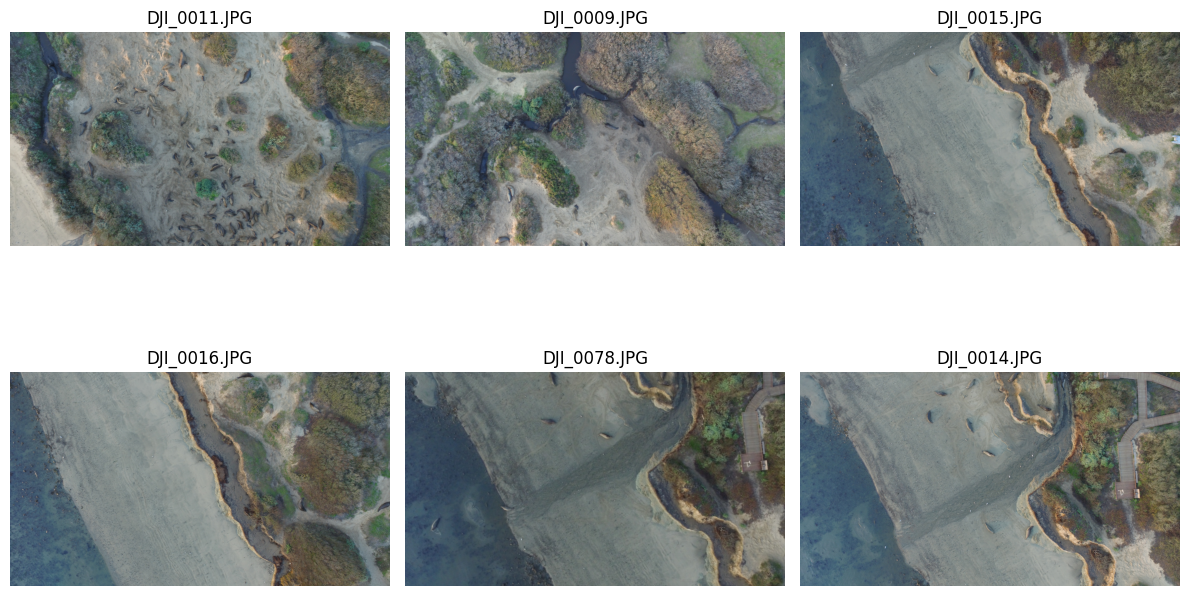

In [8]:
#now I test to see if they can be viewed
plt.figure(figsize = (12, 8))

for i, img_path in enumerate(image_paths[:6]):
    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")

plt.tight_layout()
plt.show()

YAY! It worked!

## Model Design

For this part of the project I will be setting up the code for the bounding boxes in my images. Once this step is completed I can then load in some of the pre-trained weights for the YOLOv8 model. From there I can split up my images into training and testing sets to then fine tune the YOLO model I am using.  

In [10]:
# I will test out my labeling code in a way that loops through both of my folders of images.
folders = ["20160125", "20160204"]

for folder in folders:

    folder_path = os.path.join(base_path, folder)

    jpg_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith(".jpg")
    ]

    for jpg in jpg_files:

        txt_name = os.path.splitext(jpg)[0] + ".txt"
        txt_path = os.path.join(folder_path, txt_name)

        # create empty txt file if it doesn't exist
        if not os.path.exists(txt_path):
            open(txt_path, "w").close()

    print(f"{folder}: created txt files")

for folder in folders:
    folder_path = os.path.join(base_path, folder)

    jpg_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".jpg")]
    txt_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".txt")]

    print("\nFolder:", folder)
    print("Images:", len(jpg_files))
    print("Labels:", len(txt_files))

    for txt in txt_files[:5]:
        txt_path = os.path.join(folder_path, txt)
        print(txt, "size:", os.path.getsize(txt_path), "bytes")

20160125: created txt files
20160204: created txt files

Folder: 20160125
Images: 69
Labels: 69
DJI_0046.txt size: 0 bytes
DJI_0011.txt size: 0 bytes
DJI_0009.txt size: 0 bytes
DJI_0015.txt size: 0 bytes
DJI_0016.txt size: 0 bytes

Folder: 20160204
Images: 58
Labels: 58
DJI_0002.txt size: 0 bytes
DJI_0006.txt size: 0 bytes
DJI_0003.txt size: 0 bytes
DJI_0001.txt size: 0 bytes
DJI_0058.txt size: 0 bytes


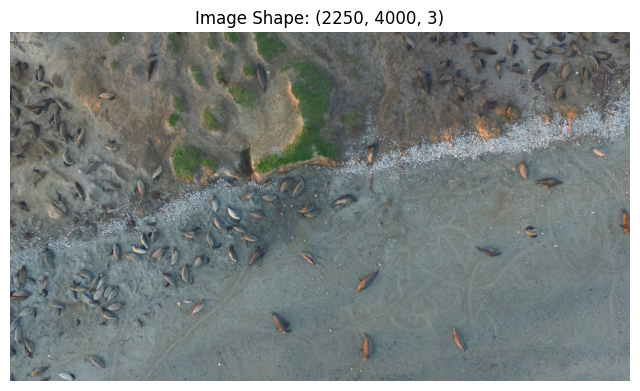

In [11]:
#now I will view one of the images
folder = "20160125"
working_dir = os.path.join(base_path, folder)
img_path = os.path.join(working_dir, "DJI_0046.JPG")
image = Image.open(img_path).convert("RGB")
image_array = np.array(image)
plt.figure(figsize=(8,8))
plt.imshow(image)
plt.title("Image Shape: " + str(np.shape(image_array)))
plt.axis("off")
plt.show()

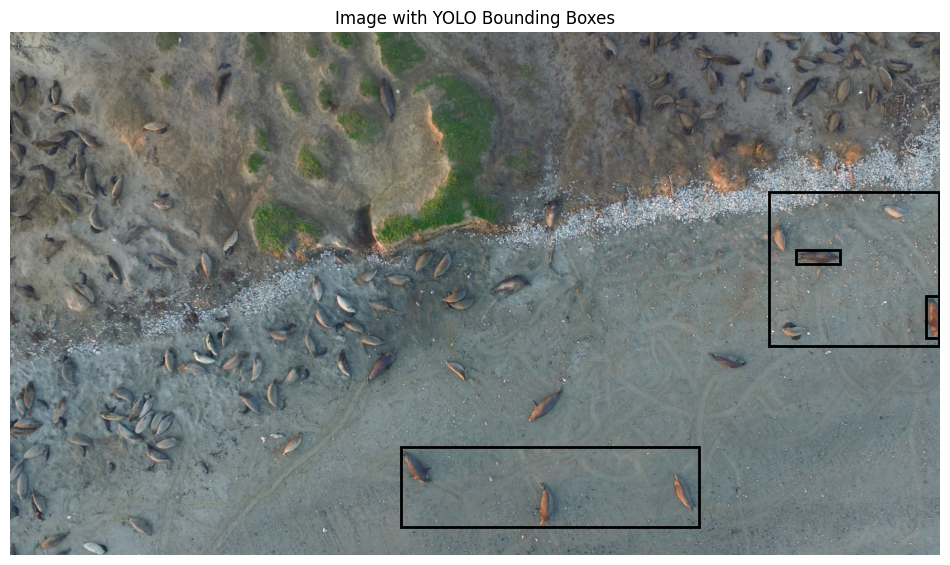

In [15]:
# now that all of my images have a ".txt" label I can start creating bounding boxes for the images and fine tuning my training set/model
# also loading a pre-trained model
model = YOLO('yolov8s.pt')
folder = "20160125"
img_name = "DJI_0046.JPG"

img_path = os.path.join(base_path, folder, img_name)
label_path = os.path.splitext(img_path)[0] + ".txt"

image = Image.open(img_path).convert("RGB")
image_array = np.array(image)

h, w = image_array.shape[:2]

plt.figure(figsize=(12, 8))
plt.imshow(image_array)
if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
    labels = np.loadtxt(label_path)

    if labels.ndim == 1:
        labels = labels.reshape(1, -1)

    for label in labels:
        class_id, x_center, y_center, box_width, box_height = label

        x_center *= w
        y_center *= h
        box_width *= w
        box_height *= h

        x1 = x_center - box_width / 2
        y1 = y_center - box_height / 2

        rect = plt.Rectangle(
            (x1, y1),
            box_width,
            box_height,
            fill=False,
            linewidth=2
        )

        plt.gca().add_patch(rect)

    plt.title("Image with YOLO Bounding Boxes")
plt.axis("off")
plt.show()